In [47]:
#importing all the libraries.  Matpoltlib is good for basic plots.
#Seaborn works best with statistical data & Pandas.
#For more specific details at: https://seaborn.pydata.org/tutorial/introduction.html
        
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
#to read sales items dataset - show 5 rows
ad_data= pd.read_csv('advertising.csv', encoding ="latin1")
ad_data.head(2)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0


In [49]:
#to show the columns & variable type
ad_data.dtypes

Daily Time Spent on Site    float64
Age                           int64
Area Income                 float64
Daily Internet Usage        float64
Ad Topic Line                   str
City                            str
Male                          int64
Country                         str
Timestamp                       str
Clicked on Ad                 int64
dtype: object

In [50]:
#Use isnull to check for null (missing data in all columns) 
ad_data.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

In [51]:
#USe descirbe method to look at the statistical basic information.
ad_data.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [52]:
#Drop any irrelavant columns. Drop method (axis = 1, signifies column) inplace = True is permanent change.
ad_data.drop(['Ad Topic Line'],axis = 1, inplace= True)
ad_data.drop(['Timestamp'], axis = 1, inplace = True)
ad_data.head(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,City,Male,Country,Clicked on Ad
0,68.95,35,61833.90,256.09,Wrightburgh,0,Tunisia,0
1,80.23,31,68441.85,193.77,West Jodi,1,Nauru,0
2,69.47,26,59785.94,236.50,Davidton,0,San Marino,0


In [53]:
#Use Value when counting rows of data. how many clicked on ad.
ad_data['Clicked on Ad'].value_counts()

Clicked on Ad
0    500
1    500
Name: count, dtype: int64

In [54]:
#To determine which columns are related to 'BUY'. The corr method used with target of BUY column.
correlation = numerical_data.corr()['Clicked on Ad']
correlation.nlargest(8).round(2)

Clicked on Ad               1.00
Age                         0.49
Sex                        -0.04
Area Income                -0.48
Daily Time Spent on Site   -0.75
Daily Internet Usage       -0.79
Name: Clicked on Ad, dtype: float64

<Axes: >

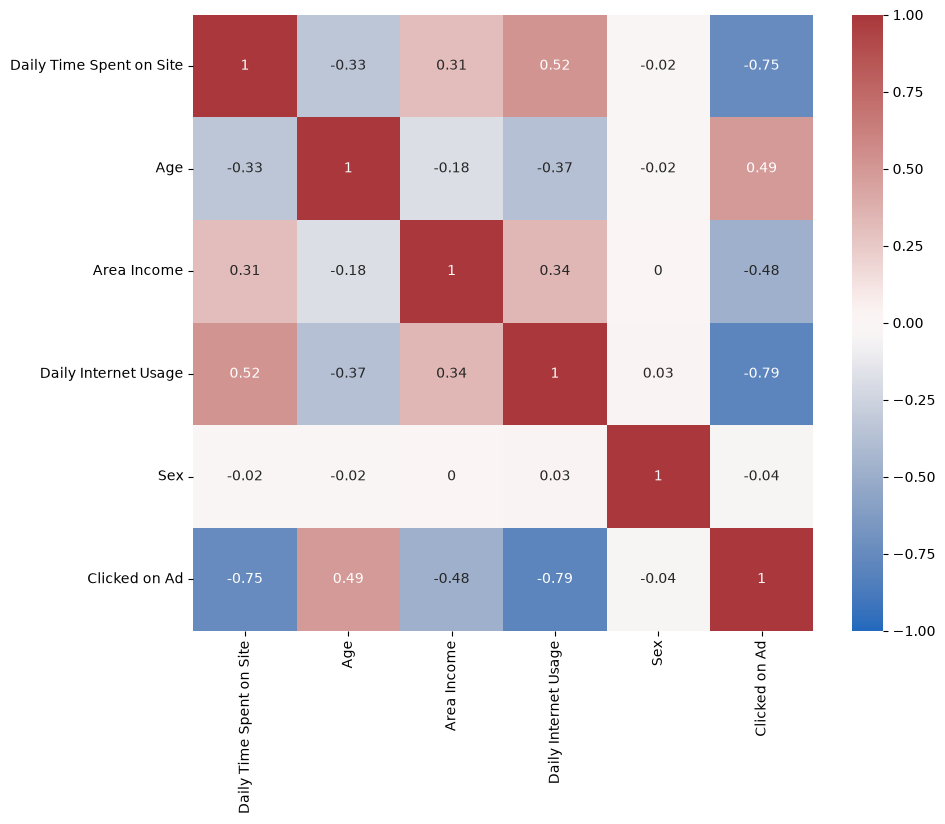

In [55]:
#Display the corelation in a heat map.
f, ax = plt.subplots(figsize=(10,8))

#Creting a variable
corr= numerical_data.corr()
sns.heatmap(corr.round(2),annot=True, vmin = -1, vmax = 1, center = 0, cmap = 'vlag')

<Axes: >

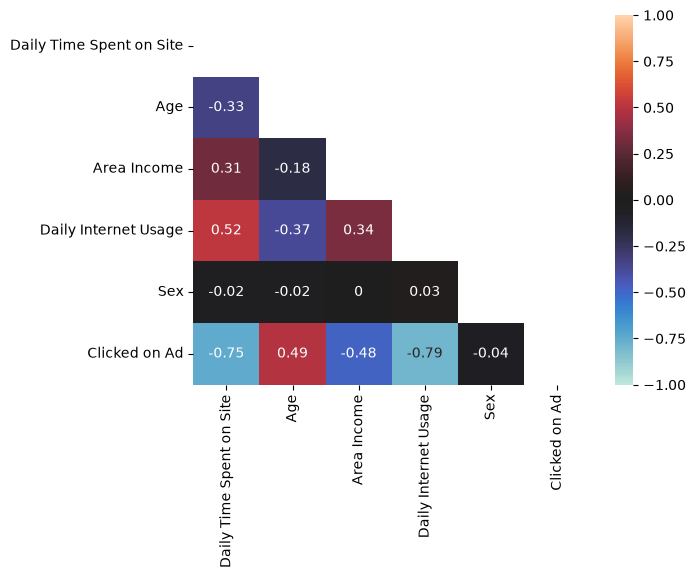

In [56]:
#to create a easier to read heatmap which 'masks' the blank (0) cells.
matrix = numerical_data.corr().round(2)
mask = np.triu(np.ones_like(matrix, dtype=bool))
sns.heatmap(matrix, annot=True, vmin = -1,vmax = 1, center =0, mask=mask)

<Axes: xlabel='Daily Time Spent on Site', ylabel='Clicked on Ad'>

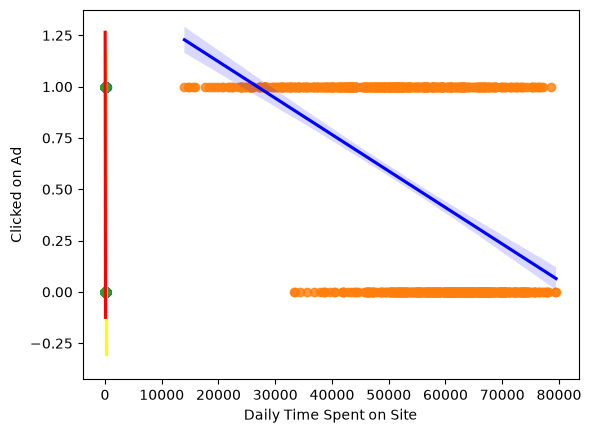

In [57]:
#Use Seaborn regplot to show a scatterplot of highest correlation value.
sns.regplot(x=numerical_data['Daily Internet Usage'], y=numerical_data['Clicked on Ad'], line_kws={'color':'yellow'})
sns.regplot(x=numerical_data['Area Income'], y=numerical_data['Clicked on Ad'], line_kws={'color':'blue'})
sns.regplot(x=numerical_data['Daily Time Spent on Site'], y=numerical_data['Clicked on Ad'], line_kws={'color':'red'})


In [58]:
#Drop any correlation variables not being used.
#numerical_data.drop(['IMAGES','FAQ','SPECS','SHIPPING','BOUGHT_TOGETHER','VIEW_SIMILAR'], axis = 1,inplace= True)
#numerical_data

##Train & Test a Algorithm Model

In [66]:
#Looking at the correlations - pick out what has medium corelation to BUY.
#import sklearn libraries to create our model.
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score 

#Key variables to try to predict clickd on ad.
predictors = numerical_data[['Age','Daily Internet Usage','Daily Time Spent on Site']]
targets = numerical_data['Clicked on Ad']
predictors.head(3)

,Age,Daily Internet Usage,Daily Time Spent on Site
0,35,256.09,68.95
1,31,193.77,80.23
2,26,236.50,69.47


In [67]:
#Construct an algorithm that can learn & make predictions for buying.
#To train and test the data - use ratio of 70:30 (70% of the data to train model, 30% to test model).
pred_train,pred_test,tar_train,tar_test = train_test_split(predictors,targets,test_size=.3, random_state = 42)
print('Predictor data for Training: ',pred_train.shape, 'Predictor data for Testing: ',pred_test.shape)

Predictor data for Training:  (700, 3) Predictor data for Testing:  (300, 3)


In [68]:
#1. Initialise the Random Forest Classifier model.
classifier = LogisticRegression()
#2. Fit using existing training arrays.
classifier.fit(pred_train.values, tar_train.values)
#3. Make predictions
predictions = classifier.predict(pred_test.values)
#4. Evaluate  the accuracy of the model & performance
acc = accuracy_score(tar_test, predictions)
print (f'True Classification Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print ('Confusion Matrix:\n', confusion_matrix(tar_test,predictions))

True Classification Accuracy: 0.9400 (94.0%)
Confusion Matrix:
 [[139   7]
 [ 11 143]]


In [69]:
#Extract the True Probabilities for New Customers
combined_data = np.array([
    [30, 100,100],   # Customer 1: age 30, 100 mins of Internet daily usage, time spent
    [50,240,20]     # Customer 2: age 50, 240 mins of Internet daily usage, time spent 
])
#Use predict_proba to get probabilities for each scenario (customer profile)
probabilities = classifier.predict_proba(combined_data)[:,1]

print('\n---Predicted Ad Clicks Likelihood --- ')
print(f'Customer 1 Probability: {probabilities[0]*100:.2f}% chance to click')
print(f'Customer 2 Probability: {probabilities[1]*100:.2f}% chance to click')


---Predicted Ad Clicks Likelihood --- 
Customer 1 Probability: 65.87% chance to click
Customer 2 Probability: 99.09% chance to click


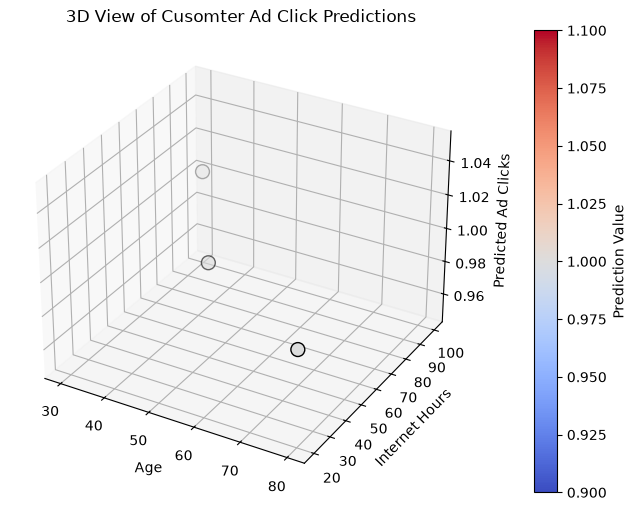

In [75]:
from mpl_toolkits.mplot3d import Axes3D
#Define the variables of the customers
ages = np.array([30,50,80])
internet_hours = np.array([100,50,20])
time_spent =np.array([80,20,20]) 
#combine into a single array
combined_data = np.column_stack((ages,internet_hours,time_spent))
predictions = classifier.predict (combined_data)

fig = plt.figure(figsize= (8,6))
ax = fig.add_subplot(111, projection = '3d')
scatter = ax.scatter(ages, internet_hours, predictions, c=predictions,cmap = 'coolwarm', 
        s=100, edgecolors= 'black')
ax.set_xlabel('Age')
ax.set_ylabel('Internet Hours')
ax.set_zlabel('Predicted Ad Clicks')
ax.set_title('3D View of Cusomter Ad Click Predictions')
fig.colorbar(scatter, ax=ax,label= 'Prediction Value', pad = 0.1)
plt.show()

In [ ]:
#from sklearn.metrics import confusion_matrix
cm = confusion_matrix(tar_test, predictions)

plt.figure(figsize=(6,5))
#creat a heatmap that formats the numbers as integers with labels 
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar= False, 
    xticklabels=['Predicted: No','Predicted: Yes'],
    yticklabels=['Actual: No','Actual: Yes'])
plt.title('Model Evaluation: Confusion Matrix',fontsize=14,pad=15)
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('True Category',fontsize=12)
plt.show()

In [ ]:
#the probability that a prospective buyer will 'BUY' the product. 
pred_prob = classifier.predict_proba(pred_test.values)
pred_prob[0,1].round(2)

In [ ]:
#Real time prediction of a user who clicks on the site will 'BUY'
#Define the test scenarios - using 4 predictor 'columns'
scenarios = {
    '60 year old & limited internet: [[60,80]],
    'Only Reviews clicked': [[1,0]],
    'Reviews & Compare Similar': [[1,1,0,0]],
    'All Predctor Pages Clicked': [[1,1,1,1]]
}
#Create an empty list ot gather rows
results_data = []

for description, features in scenarios.items():
    proba_val = classifier.predict_proba(features)[0,1]
    percentage = round(proba_val * 100)

#store scenario and results as a dictionary row.
    results_data.append({
        "Customer Scenario": description,
        "Propensity to Buy": f"{percentage}%"
   })
#To crete a dataframe to display 
df = pd.DataFrame(results_data)
df

In [ ]:
#Export the dataframe to a csv file.
df.to_csv ('customer_propensity_to_buy_report.csv',index=False)